Here we will implement rewriting query if answer is not useful.


## Loading API Key

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

## Loading Necessary Libraries

In [3]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

C:\Users\koyel\AppData\Local\Temp\ipykernel_10120\2711615123.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
c:\Users\koyel\Downloads\python_practice\ai_ml_learning_journey\genai_and_agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initial Basic Steps
- Document Loading
- Chunking 
- Embedding
- Storing to VectorDB 
- Creation of Retriever Object for Further Use
- LLM Object Creation

In [4]:
docs = DirectoryLoader(
    path = 'documents', 
    glob = '*.pdf',
    loader_cls = PyPDFLoader
).load()

In [5]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150).split_documents(docs)
embeddings = OpenAIEmbeddings(model = "text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)

- For chunking, values for parameters `chunk_size` and `chunk_overlap` is experimentally got here.

In [6]:
retriever = vector_store.as_retriever(search_kwargs = {'k': 4})

- Here as we set `k` to `4`, post retrieval 4 relevant documents will be shared where retrieval is required.

In [7]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

## Define State
- `state` is a class which carries variables and their values at different steps of the workflow.
- Variables in `state` are modified as workflow proceeds.
- Variables:
    - `question`: user query
    - `need_retrieval`: boolean parameter indicating retrieval of documents is needed or not for particular query going to vector database
    - `docs`: list of all retrieved docs
    - `relevant_docs`: list of relevant documents
    - `answer`: final answer which will be showed to user
    - `issup`: boolean parameter indicating RAG generated answer is grounded in relevant documents or not
    - `evidence`: list of strings from relevant documents which supports the answer in case of fully/partially supported
    - `retries`: number of times to regenerate answer from retrieved documents if answer is not supported by evidence
    - `isuse`: boolean parameter indicating RAG generated answer is useful or not
    - `use_reason`: reason mentioning why RAG generated answer seems useful to LLM
    - `retrieval_query`: Rewritten query in case RAG generated answer is not useful for given query (may it be initial user query or rewritten query at its previous try)
    - `rewrite_tries`: maximum number of retries to do to rewrite the query and regenerate RAG's answer 

- Can add description in schema itself.
- Here `retrieval_query` and `rewrite_tries` are newly added in `state` of the workflow. Post rewriting query this `retrieval_query` is actually what we send to retriever.

In [8]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    
    docs: List[Document]
    relevant_docs: list[Document]

    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str

    retrieval_query: str
    rewrite_tries: int

## Decision on Requirement of Retrival of Documents
- This below part is to output schema of structured LLM , prompt and node regarding query needs RAG or LLM can answer from its parametric knowledge.

#### Output Schema for Node `decide_retrieval`
- Class `RetrieveDecicision` has only one variable `should_retrieve` which is a boolean variable as this output schema will be used for getting structured output from node `decide_retrieval`.

In [9]:
class RetrieveDecicision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False"
    )

#### Prompt for Node `decide_retrieval`

In [10]:
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve = True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve = False for general explanations, definitions, or reasoning taht doesn't need sources.\n"
            "- If unsure. choose True."
        ),
        ("human", "Question: {question}")
    ]
)

#### Structured LLM for Node `decide_retrieval`
- **`IMPORTANT`**: NO `.content` for structured output.

In [11]:
should_retrieve_llm = llm.with_structured_output(RetrieveDecicision)

#### Define Node `decide_retrieval`

In [12]:
def decide_retrieval(state: "State"):
    decision: RetrieveDecicision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question = state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

## Direct Answer Generation
- Below part will generate answer for queries which can be answered by LLM directly without retrieving  document.

#### Prompt for Node `generate_direct`

In [13]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specifics sources, say:\n"
            "I don't know based on my general knowledge."
        ),
        ("human", "{question}")
    ]
)

#### Define Node `generate_direct`

In [14]:
def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question = state["question"]
        )
    )
    return {
        "answer": out.content
    }

## Retrieval of Documents
- Node `retrieve` will retrieve document where required.
#### Define Node `retrieve`
- This nodes does not require any output schema or prompt.
- It just needs `retriever` object defined in `Initial Basic Steps`.
- This node will be used in case `decide_retrieval` decides that query requires to retrieve document. 
- Here is a new addition in this node definition, we can retrieve document based on rewritten query if rewriting original question as well. It can still retrieve documents based on original query as well.

In [15]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}

## Evaluation of Relevance of Retrieved Documents
#### Output Schema for Node `is_relevant`
- It is working with LLM with output schema `RelevanceDecision` which is having a boolean variable which tells relevant or not.

In [16]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description = "true if the documment helps answer the question, else False."
    )

#### Prompt for Node `is_relevant`

In [17]:
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a judging document relavance.\n"
            "Return the JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        )
    ]
)

#### Structured LLM for Node `is_relevant`

In [18]:
relevance_llm = llm.with_structured_output(RelevanceDecision)

#### Define Node `is_relevant`
- This node present will decide relevance of retrieved documents.

In [19]:
def is_relevant(state: State):

    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question = state["question"],
                document = doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

## Generating Answer by RAG
#### Prompt for Node `generate_from_context`

In [20]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        )
    ]
)

#### Define Node `generate_from_context`
- The `generate_from_context` node present in below section will generate answer based on relevant documents + prompt.

In [21]:
def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state["question"],
            context = context
        )
    )
    return {"answer": out.content, "context": context}

#### Define Node `no_relevant_docs`

In [22]:
def no_relevant_docs(satte: State):
    return {"answer": "No answer found.", "context":""}

## Checking Hallucination of RAG Generated Answer

#### Output Schema for Node `is_sup`

In [23]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

#### Prompt for Node `is_sup`

In [24]:
issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

#### Structured Output LLM for Node `is_sup`

In [25]:
issup_llm = llm.with_structured_output(IsSUPDecision)

#### Define Node `is_sup`

In [26]:
def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}

## Accepting the RAG Generated Answer
- This node `accept_answer` will work if answer will be fully supported by retrieved documents.
#### Define Node `accept_answer`
- From this node workflow will proceed towards `End`.
- It will keep answer as-is.

In [27]:
def accept_answer(state: State):
    return {} 

## Regeneration of RAG Generated Answer
- Here we can retry to generate answer again via LLM using retrieved documents if previous answer is not grounded in retrieved documents.
- Here this previous answer may be answer to original user's query or it may be answer to the query rewritten in its previous retry.
- This regeneration will happen on output of node `is_sup`.
- It will work in case of retrieval is required.
- To NOT get involved in infinite loop, we will keep a maximum number of permissbale retry.

In [28]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

In [29]:
def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

## Checking Usefulness of RAG Generated Answer
- Here we will evaluate usefulness of RAG generated recent answer from user query.
- Here this recent answer may be the answer either generated at first try or recent retry.

#### Output Schema for Node `is_use`

In [30]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

#### Prompt for Node `is_use`

In [31]:
isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

#### Structured Output LLM for Node `is_use`

In [32]:
isuse_llm = llm.with_structured_output(IsUSEDecision)

#### Define Node `is_use`

In [33]:
def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

## Rewriting Query 
- We will rewrite latest query if RAG generated latest answer is NOT useful post maximum retry applied on regeneration of fully supported answer (grounded on retrieved docuemnt).
- Here this latest query may be original user's query or it may be rewritten query in latest retry during usefulness check.
- Also RAG generated latest answer refers to answer to user's original query (can be post retry or initial run) or answer rewritten query in latest retry during usefulness check

#### Output Schema for Node `rewrite_question`

In [34]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

#### Prompt for Node `rewrite_question`

In [35]:
rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

#### Structured Output LLM for Node `rewrite_question`

In [36]:
rewrite_llm = llm.with_structured_output(RewriteDecision)

#### Define Node `rewrite_question`

In [37]:
def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

## Routing Node Function 
- `route_after_decide` will decide to retrieve documents or directly send query to answer generating LLM.
- This will work based on output of `decide_retrieval`.

In [38]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

- `route_after_relevance` will decide next node based on presence of relevant documents.

In [39]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_relevant_docs"

- In `route_after_issup` to NOT get involved in infinite loop, we will keep a maximum number of permissbale retry.

In [40]:
MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

In [41]:
MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_relevant_docs"]:
    if state.get("isuse") == "useful":
        return "END"
    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_relevant_docs"
    return "rewrite_question"

## Define Graph
-  `retrieve` node is temporary end for retrieval path, as reasons discussed earlier.

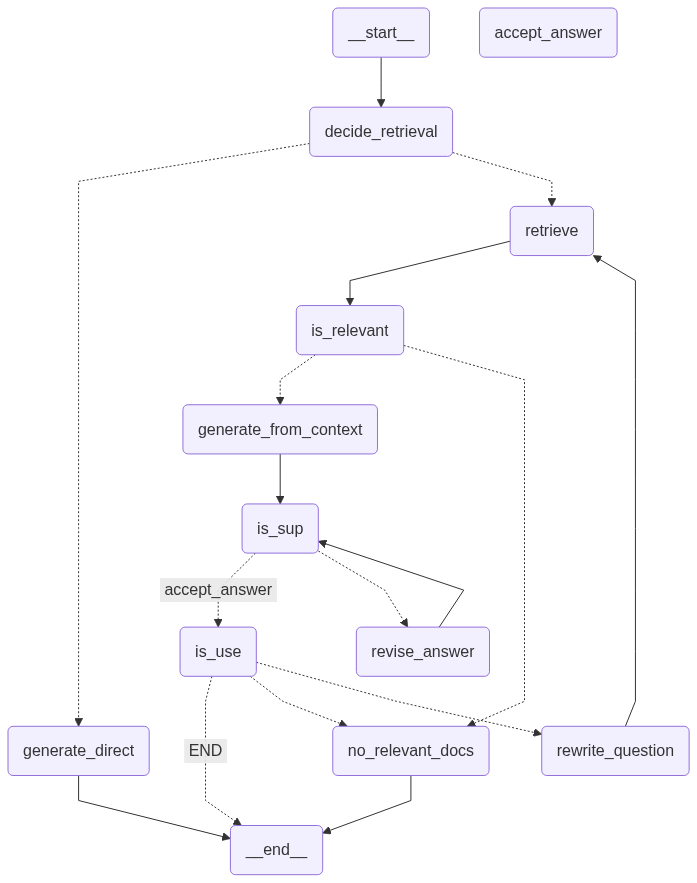

In [42]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)
g.add_node("is_sup", is_sup)

g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)
g.add_node("is_use", is_use)
# rewrite question for better retrieval
g.add_node("rewrite_question", rewrite_question)


g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve"
    }
)


g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context", 
        "no_relevant_docs": "no_relevant_docs"
    },
)

# If no answer found, end
g.add_edge("no_relevant_docs", END)

# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported goes to IsUSE
    {
        "accept_answer": "is_use", 
        "revise_answer": "revise_answer"
    },
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify

# IsUSE routing
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_relevant_docs": "no_relevant_docs",
    },
)

g.add_edge("rewrite_question", "retrieve")

app = g.compile()
app

## Test on Questions
- Now we will see the decision on retrieval needed or not with two questions.

In [48]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe Novantra's company culture.",
    "retrieval_query": "What is the company culture of Novantra",  
    "rewrite_tries": 0,                                      
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe Novantra's company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 1

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 2

Relevant docs (source/page):
  1. source=documents\Company_Profile.pdf, page=3
  2. source=documents\Company_Profile.pdf, page=1

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - Noventra promotes: • Flexible working • Continuous learning • Inclusive workplace • Cross-functional collaboration • Innovation through experimentation • Employee wellbeing
   - Encourage teamwork across departments and customers.

Usefulness (IsUSE):
  isuse: useful
  reason: The answer provides specific aspects of Novantra's company culture.

Final Answer:
- "Noventra promotes: • Flexible working • Continuous learning • Inclusive workplace • Cross-functional collaboration • Innovation through experimentation • Employee wellbeing"
- "Encourage teamwork across departments and customers

In [44]:
# how many employees does naxa ai have?
# describe nexaai's company culture
# do nexaai plans include a free trial? If yes, how may days?

In [49]:
print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 2
issup: fully_supported
evidence: ['Noventra promotes: • Flexible working • Continuous learning • Inclusive workplace • Cross-functional collaboration • Innovation through experimentation • Employee wellbeing', 'Encourage teamwork across departments and customers.']
answer: - "Noventra promotes: • Flexible working • Continuous learning • Inclusive workplace • Cross-functional collaboration • Innovation through experimentation • Employee wellbeing"
- "Encourage teamwork across departments and customers."


In [50]:
print(result.get("retries"))

1


In [51]:
for doc in result['relevant_docs']:
    print(doc.page_content)

Global Presence 
Regional offices are located in: 
• North America 
• Europe 
• Asia-Pacific 
• Middle East 
The company supports customers globally through remote implementation teams and certified 
solution partners. 
 
Corporate Culture 
Noventra promotes: 
• Flexible working 
• Continuous learning 
• Inclusive workplace 
• Cross-functional collaboration 
• Innovation through experimentation 
• Employee wellbeing
Encourage teamwork across departments and customers. 
Accountability 
Take ownership of commitments and continuously improve outcomes. 
Learning 
Promote continuous skill development and experimentation. 
 
Company History 
Noventra Systems was founded in 2019 with the goal of modernizing enterprise knowledge 
management. 
Initially focused on document search solutions, the company later expanded into AI-powered 
assistants, workflow automation, analytics platforms, and enterprise collaboration software.


## TODO:
- Understand behaviour of rewrite query well.
- Also why we are sending `retrieval_query` in initial state? Should it be not created during workflow if it will face need of regeneration of query?